<a href="https://colab.research.google.com/github/carrisian/del-big-data-al-modelo-predictivo/blob/main/colab/Medidas%20contaminaci%C3%B3n%20ayuntamientos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis de la Calidad del Aire Urbano: Murcia y Cartagena

Este cuaderno constituye el segundo bloque de análisis del Trabajo Fin de Máster. Tras caracterizar los episodios de polvo sahariano, en esta sección se evalúa la **contaminación de origen antropogénico**.

Como indicador principal se utiliza el **Dióxido de Nitrógeno (NO₂)**, dado que cuenta con una vida atmosférica más corta y está directamente correlacionado con los procesos de combustión interna del tráfico rodado en entornos urbanos.

## 1. Tendencia Temporal: Evolución de NO₂

Para esta visualización, hemos aplicado una **media móvil de 30 días (ventana de 240 registros)**. Este procesamiento permite eliminar el "ruido" de la variabilidad diaria (ciclos día/noche y fines de semana) y observar la tendencia estructural a largo plazo.

*   **Interpretación:** La línea roja discontinua representa el inicio de las medidas de gestión de tráfico en 2023. Observaremos si existe un cambio de pendiente significativo en los niveles de emisión tras la implementación de políticas urbanas.

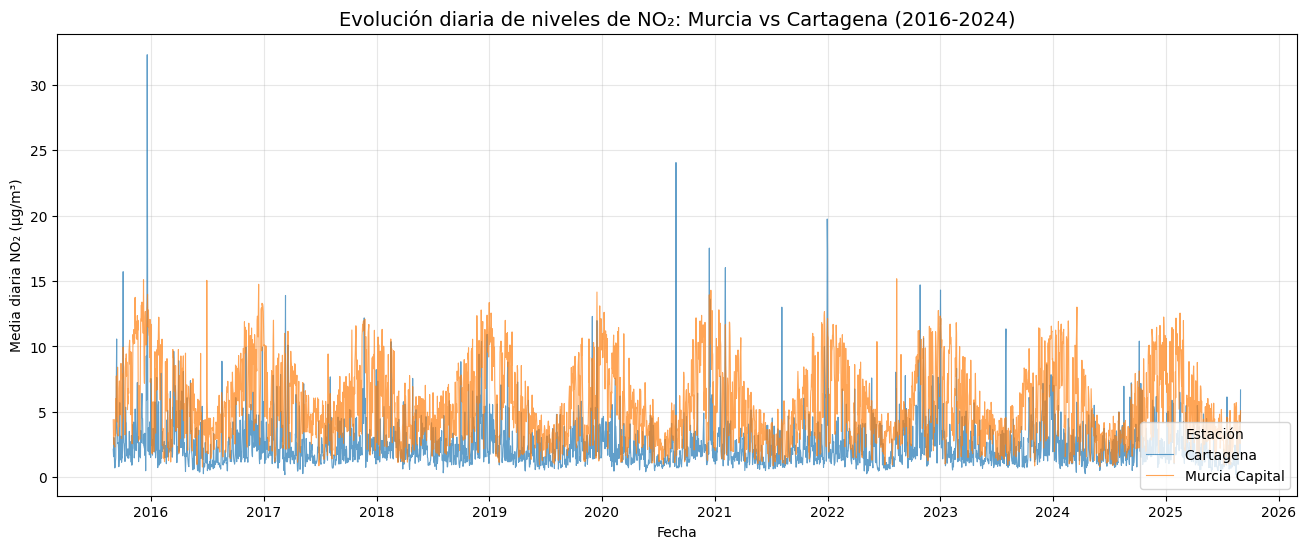

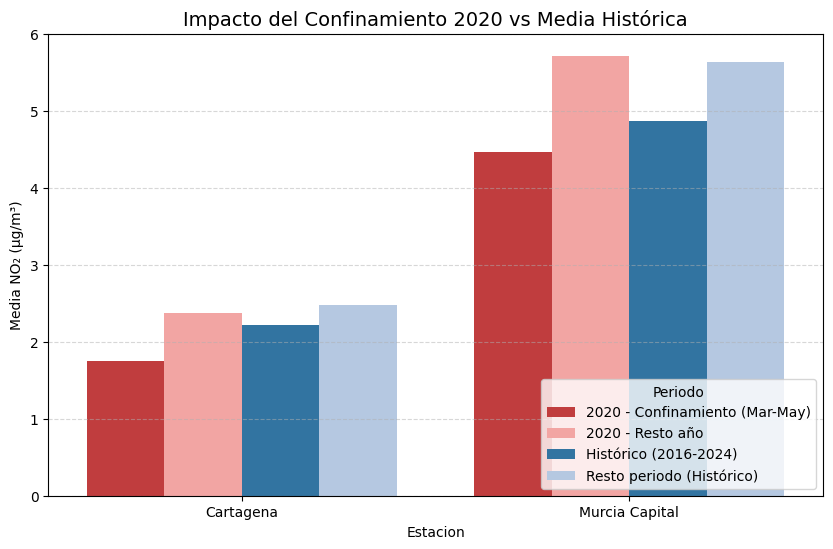

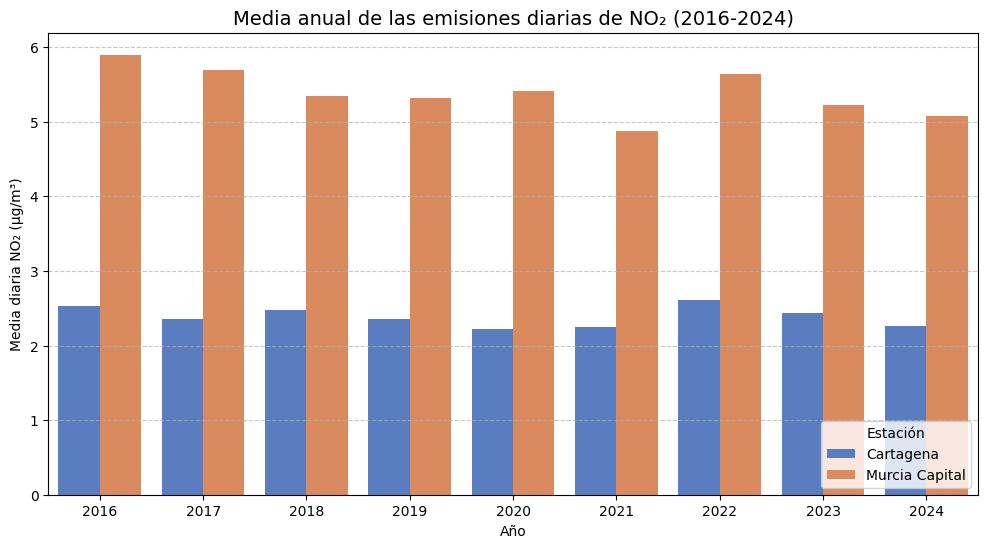

✅ Análisis finalizado. Gráficas y tablas guardadas en: /content/drive/MyDrive/TFM_Profesorado/Analisis_Contaminacion_Urbana


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from google.colab import drive

# 1. Configuración de entorno
if not os.path.isdir('/content/drive'):
    drive.mount('/content/drive')

PATH_BASE = "/content/drive/MyDrive/TFM_Profesorado/"
RUTA_OUTPUT = os.path.join(PATH_BASE, "Analisis_Contaminacion_Urbana")
os.makedirs(RUTA_OUTPUT, exist_ok=True)

# 2. Carga y Preparación
df = pd.read_parquet(f"{PATH_BASE}Murcia_Dataset_Completo_Global_3H.parquet")
df['time'] = pd.to_datetime(df['time'])
df_urbano = df[df['Estacion'].isin(['Murcia Capital', 'Cartagena'])].copy()
df_urbano['fecha'] = df_urbano['time'].dt.date
df_urbano['anio'] = df_urbano['time'].dt.year

# --- GRÁFICA 1: Evolución Diaria (2016-2024) ---
df_diario = df_urbano.groupby(['fecha', 'Estacion'])['NO2'].mean().reset_index()

plt.figure(figsize=(16, 6))
sns.lineplot(data=df_diario, x='fecha', y='NO2', hue='Estacion', linewidth=0.8, alpha=0.7)
plt.title("Evolución diaria de niveles de NO₂: Murcia vs Cartagena (2016-2024)", fontsize=14)
plt.ylabel("Media diaria NO₂ (µg/m³)")
plt.xlabel("Fecha")
plt.legend(loc='lower right', title="Estación")
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(RUTA_OUTPUT, "Evolucion_Diaria_NO2.png"), dpi=300)
plt.show()

# --- GRÁFICA 2: Comparativa Pandemia vs Histórico ---
def asignar_categoria(row):
    if row['anio'] == 2020:
        return '2020 - Confinamiento (Mar-May)' if 3 <= row['time'].month <= 5 else '2020 - Resto año'
    else:
        return 'Histórico (2016-2024)' if 3 <= row['time'].month <= 5 else 'Resto periodo (Histórico)'

df_urbano['Categoria'] = df_urbano.apply(asignar_categoria, axis=1)
# Excluimos el año 2020 del cálculo histórico para que la comparación sea justa
resumen_pandemia = df_urbano[df_urbano['anio'] != 2020].copy()
resumen_pandemia = pd.concat([resumen_pandemia, df_urbano[df_urbano['anio'] == 2020]])
resumen_pandemia = resumen_pandemia.groupby(['Estacion', 'Categoria'])['NO2'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=resumen_pandemia, x='Estacion', y='NO2', hue='Categoria',
            palette=['#d62728', '#ff9896', '#1f77b4', '#aec7e8'])
plt.title("Impacto del Confinamiento 2020 vs Media Histórica", fontsize=14)
plt.ylabel("Media NO₂ (µg/m³)")
plt.legend(loc='lower right', title="Periodo")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.savefig(os.path.join(RUTA_OUTPUT, "Impacto_Pandemia_vs_Historico.png"), dpi=300)
plt.show()

# --- GRÁFICA 3: Media Anual (Barras) ---
media_anual = df_urbano.groupby(['anio', 'Estacion'])['NO2'].mean().reset_index()
# Aseguramos el rango estricto 2016-2024
media_anual = media_anual[(media_anual['anio'] >= 2016) & (media_anual['anio'] <= 2024)]

plt.figure(figsize=(12, 6))
sns.barplot(data=media_anual, x='anio', y='NO2', hue='Estacion', palette='muted')
plt.title("Media anual de las emisiones diarias de NO₂ (2016-2024)", fontsize=14)
plt.ylabel("Media diaria NO₂ (µg/m³)")
plt.xlabel("Año")
plt.legend(loc='lower right', title="Estación")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(RUTA_OUTPUT, "Media_Anual_NO2_Barras.png"), dpi=300)
plt.show()

# Exportar tabla resumen final
media_anual.to_csv(os.path.join(RUTA_OUTPUT, "Tabla_NO2_Media_Anual.csv"), index=False)
print(f"✅ Análisis finalizado. Gráficas y tablas guardadas en: {RUTA_OUTPUT}")
